# PCA + ACF curve analysis


## Set up
### Imports

In [1]:
# pathing + config
from pathlib import Path
import sys
import yaml
import os

# Locate repo root
repo_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "config" / "config.yml").exists()
)

# Add code directory to import path
code_dir = repo_root / "code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

# Load base project config
config_path = repo_root / "config" / "config.yml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

# Load dedicated PCA->ACF config
pca_config_path = repo_root / "config" / "pca_config.yml"
if not pca_config_path.exists():
    raise FileNotFoundError(f"Missing PCA config: {pca_config_path}")

pca_config = yaml.safe_load(pca_config_path.read_text(encoding="utf-8"))
if not isinstance(pca_config, dict) or "pca_acf" not in pca_config:
    raise KeyError("Expected top-level key 'pca_acf' in config/pca_config.yml")

main_params = pca_config["pca_acf"]
print(f"Loaded configs:\n- {config_path}\n- {pca_config_path}")


Loaded configs:
- c:\Users\ESPCI\Documents\GitHub\fUSPredict\config\config.yml
- c:\Users\ESPCI\Documents\GitHub\fUSPredict\config\pca_config.yml


In [2]:
# Package imports
from IPython.display import display
from IPython import get_ipython

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

import numpy as np
from sklearn.decomposition import PCA
from scipy.signal import welch

from utils.preprocessing.io import load_stage_npz, derive_session_id_from_path
from utils.eda.pca import plot_scree_cumulative
from utils import helper_functions as hf


In [3]:
# Inline backend
USE_WIDGET = False
ipy = get_ipython()
backend_mode = "inline"
if ipy is not None:
    try:
        ipy.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
print(f"Matplotlib backend: {matplotlib.get_backend()} | mode={backend_mode}")

# Core paths from project config
deriv_root = repo_root / config["paths"]["preprocessing"]
subjects = config["subjects"]["all"]

# Main run selection from dedicated PCA config
run_selection = main_params["selection"]
sample_display_cfg = main_params.get("sample_display", {})

sample_subject = str(run_selection["subject"])
sample_session_idx = int(run_selection["session_idx"])
default_condition = str(run_selection["condition"])
default_variant = str(run_selection["variant"])
sample_condition = str(sample_display_cfg.get("condition") or default_condition)
sample_variant = str(sample_display_cfg.get("variant") or default_variant)
sample_display_session_idx = int(sample_display_cfg.get("session_idx") if sample_display_cfg.get("session_idx") is not None else sample_session_idx)

# Figure saving
PLOT_SAVE_ENABLED = True
plot_output_dir = deriv_root / "pca_acf" / "figures"
plot_output_dir.mkdir(parents=True, exist_ok=True)


def _slug(text):
    s = str(text)
    return "".join(ch if (ch.isalnum() or ch in {"-", "_"}) else "-" for ch in s)


def _save_fig(fig, filename, dpi=150):
    if not PLOT_SAVE_ENABLED:
        return None
    out = plot_output_dir / filename
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    return out


# Keep less-critical controls local to later cells where they are used.

def _flatten_dict(d, parent=""):
    out = {}
    for k, v in d.items():
        key = f"{parent}.{k}" if parent else str(k)
        if isinstance(v, dict):
            out.update(_flatten_dict(v, key))
        else:
            out[key] = v
    return out


main_params_table = pd.Series(_flatten_dict(main_params), name="value").to_frame()
display(main_params_table)

# Section 1 outputs
section1_outputs = {
    "repo_root": repo_root,
    "config": config,
    "pca_config": pca_config,
    "main_params": main_params,
    "main_params_table": main_params_table,
    "sample_condition": sample_condition,
    "sample_variant": sample_variant,
    "sample_display_session_idx": sample_display_session_idx,
}


Matplotlib backend: inline | mode=inline


,value
selection.subject,secundo
selection.session_idx,2
selection.condition,unfiltered
selection.variant,zscore
selection.t_start,None
selection.t_stop,None
sample_display.condition,None
sample_display.variant,None
sample_display.session_idx,None
pca.mode,var_keep


### Load data

In [4]:
sel = main_params["selection"]
sample_cfg = main_params.get("sample_display", {})
data_condition = str(sample_cfg.get("condition") or sel["condition"])
data_variant = str(sample_cfg.get("variant") or sel["variant"])
display_session_idx = int(sample_cfg.get("session_idx") if sample_cfg.get("session_idx") is not None else sel["session_idx"])
print(f"Sample plot source -> condition={data_condition} | variant={data_variant} | session_idx={display_session_idx}")

# Loads all sessions into memory (frames) for the chosen condition/variant.
# Later plotting cells should only render one display session per subject.
data_by_subject = {}
display_session_by_subject = {}
rows = []

for subject in subjects:
    subject_root = deriv_root / subject
    if data_variant == "raw":
        data_dir = subject_root / "baseline_only"
        pattern = "baseline_*_baseline_extracted.npz"
    else:
        data_dir = subject_root / "baseline_only_standardized"
        pattern = f"baseline_*_{data_condition}_standardized_{data_variant}.npz"

    files = sorted(data_dir.glob(pattern))
    if not files:
        print(f"[skip] {subject}: no files in {data_dir} matching {pattern!r}")
        data_by_subject[subject] = []
        continue

    subject_sessions = []
    for p in files:
        frames_raw, stage_meta = load_stage_npz(str(p))
        frames = np.asarray(frames_raw, dtype=np.float32)
        if frames.ndim == 4 and frames.shape[1] == 1:
            frames = frames[:, 0]
        if frames.ndim != 3:
            raise ValueError(f"{subject} | {p.name}: expected (T,H,W), got {frames.shape}")

        T, H, W = [int(v) for v in frames.shape]
        V = int(H * W)
        session_id = str(stage_meta.get("session_id", "")).strip() if isinstance(stage_meta, dict) else ""
        if not session_id:
            session_id = derive_session_id_from_path(p)

        nan_count = int(np.isnan(frames).sum())
        if not np.isfinite(frames).all():
            raise ValueError(f"{subject} | {session_id}: non-finite values in frames")

        pack = {
            "subject": str(subject),
            "session_id": str(session_id),
            "path": str(p),
            "frames": frames,
            "stage_meta": stage_meta,
            "T": T,
            "H": H,
            "W": W,
            "V": V,
            "dtype": str(frames.dtype),
            "min": float(np.min(frames)),
            "max": float(np.max(frames)),
            "nan_count": nan_count,
        }
        subject_sessions.append(pack)
        rows.append({k: pack[k] for k in ["subject", "session_id", "path", "T", "H", "W", "V", "dtype", "min", "max", "nan_count"]})

    data_by_subject[subject] = subject_sessions

    d_idx = int(np.clip(display_session_idx, 0, len(subject_sessions) - 1))
    display_session_by_subject[subject] = subject_sessions[d_idx]

    print(
        f"Loaded {subject}: sessions={len(subject_sessions)} | "
        f"display_session={display_session_by_subject[subject]['session_id']}"
    )

session_df = pd.DataFrame(rows)
if not session_df.empty:
    display(session_df.head(20))

# Backward-compatible single-session aliases for immediate next sections (first subject's display session).
first_subject = next((s for s in subjects if len(data_by_subject.get(s, [])) > 0), None)
if first_subject is None:
    raise RuntimeError("No sessions loaded for any configured subject.")

display_pack = display_session_by_subject[first_subject]
frames = display_pack["frames"]
T, H, W, V = display_pack["T"], display_pack["H"], display_pack["W"], display_pack["V"]
X = frames.reshape(T, V).astype(np.float32, copy=False)
session_id = display_pack["session_id"]
selected_npz_path = display_pack["path"]
stage_meta = display_pack["stage_meta"]

data_info = {
    "subject": first_subject,
    "session_id": session_id,
    "condition": data_condition,
    "variant": data_variant,
    "selected_npz_path": selected_npz_path,
    "T": T,
    "H": H,
    "W": W,
    "V": V,
    "dtype": display_pack["dtype"],
    "min": display_pack["min"],
    "max": display_pack["max"],
    "nan_count": display_pack["nan_count"],
}
print(
    f"Display baseline for next section: subject={first_subject} session={session_id} "
    f"frames={frames.shape}"
)

# Section 2 outputs
section2_outputs = {
    "data_by_subject": data_by_subject,
    "display_session_by_subject": display_session_by_subject,
    "session_df": session_df,
    "frames": frames,
    "X": X,
    "T": T,
    "H": H,
    "W": W,
    "V": V,
    "session_id": session_id,
    "selected_npz_path": str(selected_npz_path),
    "stage_meta": stage_meta,
    "data_info": data_info,
}


Sample plot source -> condition=unfiltered | variant=zscore | session_idx=2
Loaded secundo: sessions=34 | display_session=Se01102020
Loaded gus: sessions=13 | display_session=Gu06102020


,subject,session_id,path,T,H,W,V,dtype,min,max,nan_count
0,secundo,Se01072020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,526,112,112,12544,float32,-3.0,3.0,0
1,secundo,Se01092020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,536,112,112,12544,float32,-3.0,3.0,0
2,secundo,Se01102020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,502,112,112,12544,float32,-3.0,3.0,0
3,secundo,Se01122020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,538,112,112,12544,float32,-3.0,3.0,0
4,secundo,Se02122020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,537,112,112,12544,float32,-3.0,3.0,0
5,secundo,Se03022020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,240,112,112,12544,float32,-3.0,3.0,0
6,secundo,Se03092020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,518,112,112,12544,float32,-3.0,3.0,0
7,secundo,Se04022020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,268,112,112,12544,float32,-3.0,3.0,0
8,secundo,Se04032020,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,906,112,112,12544,float32,-3.0,3.0,0
9,secundo,Se04062021,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,252,112,112,12544,float32,-3.0,3.0,0


Display baseline for next section: subject=secundo session=Se01102020 frames=(502, 112, 112)


---
## PCA 
This section will compute the pca and plot the scree+cumulative EVR plots, the pc score time traces, and the spatial loading maps. PCA fit for one selected session per subject

In [5]:
pca_cfg = main_params["pca"]
kdrop_cfg = main_params["k_drop"]

pca_mode = str(pca_cfg.get("mode", "var_keep")).strip().lower()
var_keep = float(pca_cfg.get("var_keep", 0.95))
n_components_cfg = pca_cfg.get("n_components", None)
standardize_features = bool(pca_cfg.get("standardize_features", False))

k_drop_list_cfg = [int(k) for k in kdrop_cfg.get("k_drop_list", [0, 1, 2, 5, 10, 20, 50])]
pcs_to_inspect_cfg = [int(pc) for pc in kdrop_cfg.get("pcs_to_inspect", [1, 2, 3])]

if pca_mode not in {"var_keep", "n_components"}:
    raise ValueError(f"Unsupported pca.mode={pca_mode!r}; expected 'var_keep' or 'n_components'")
if pca_mode == "var_keep" and not (0.0 < var_keep <= 1.0):
    raise ValueError(f"pca.var_keep must be in (0,1], got {var_keep}")

pca_results = {}
summary_rows = []

for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue

    session_id = str(disp["session_id"])
    frames_s = np.asarray(disp["frames"], dtype=np.float32)
    T, H, W = [int(v) for v in frames_s.shape]
    V = int(H * W)

    X_raw = frames_s.reshape(T, V).astype(np.float64, copy=False)

    # Optional per-feature z-scoring before PCA.
    if standardize_features:
        feat_mu = np.mean(X_raw, axis=0, keepdims=True)
        feat_sd = np.std(X_raw, axis=0, keepdims=True)
        feat_sd = np.where(feat_sd <= 1e-8, 1.0, feat_sd)
        X_fit = (X_raw - feat_mu) / feat_sd
    else:
        feat_mu = np.zeros((1, V), dtype=np.float64)
        feat_sd = np.ones((1, V), dtype=np.float64)
        X_fit = X_raw

    pca_model = PCA(svd_solver="full")
    scores_s = pca_model.fit_transform(X_fit).astype(np.float32)
    components_s = np.asarray(pca_model.components_, dtype=np.float32)  # [K, V]
    mean_s = np.asarray(pca_model.mean_, dtype=np.float32)              # [V]
    evr_s = np.asarray(pca_model.explained_variance_ratio_, dtype=np.float32)
    evr_cum_s = np.cumsum(evr_s, dtype=np.float64).astype(np.float32)

    K = int(evr_s.size)
    if K == 0:
        raise ValueError(f"PCA returned zero components for {subject}/{session_id}")

    if pca_mode == "n_components":
        if n_components_cfg is None:
            raise ValueError("pca.n_components must be set when pca.mode='n_components'")
        k_keep = int(np.clip(int(n_components_cfg), 1, K))
    else:
        k_keep = int(np.searchsorted(evr_cum_s, var_keep, side="left") + 1)
        k_keep = int(np.clip(k_keep, 1, K))

    valid_k_drop = sorted([k for k in k_drop_list_cfg if 0 <= int(k) < K])
    pcs_to_inspect = [pc for pc in pcs_to_inspect_cfg if 1 <= int(pc) <= K]

    key = (str(subject), str(session_id))
    pca_results[key] = {
        "subject": str(subject),
        "session_id": str(session_id),
        "path": str(disp["path"]),
        "T": T,
        "H": H,
        "W": W,
        "V": V,
        "K": K,
        "pca_model": pca_model,
        "scores": scores_s,
        "components": components_s,
        "components_hw": components_s.reshape(K, H, W),
        "mean_": mean_s,
        "evr": evr_s,
        "evr_cum": evr_cum_s,
        "k_keep": k_keep,
        "valid_k_drop": valid_k_drop,
        "pcs_to_inspect": pcs_to_inspect,
        "standardize_features": bool(standardize_features),
        "feature_mu": feat_mu.astype(np.float32),
        "feature_sd": feat_sd.astype(np.float32),
    }

    summary_rows.append(
        {
            "subject": str(subject),
            "session_id": str(session_id),
            "T": T,
            "H": H,
            "W": W,
            "V": V,
            "K": K,
            "k_keep": int(k_keep),
            "evr_pc1": float(evr_s[0]) if K > 0 else np.nan,
            "evr_sum_k_keep": float(evr_cum_s[k_keep - 1]),
            "n_valid_k_drop": int(len(valid_k_drop)),
        }
    )

pca_summary_df = pd.DataFrame(summary_rows)
if not pca_summary_df.empty:
    pca_summary_df = pca_summary_df.sort_values(["subject", "session_id"], kind="stable").reset_index(drop=True)

display(pca_summary_df)


,subject,session_id,T,H,W,V,K,k_keep,evr_pc1,evr_sum_k_keep,n_valid_k_drop
0,gus,Gu06102020,549,112,112,12544,549,493,0.058263,0.950092,5
1,secundo,Se01102020,502,112,112,12544,502,458,0.037411,0.950348,5


### Section Outputs
store outputs in variables for later use: pca, scores, components, explained_var_ratio, mean_, spatial_maps

#### EVR plots for one display session per subject

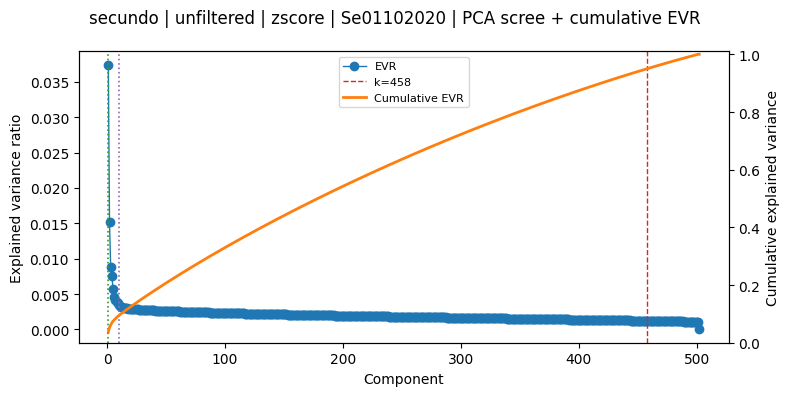

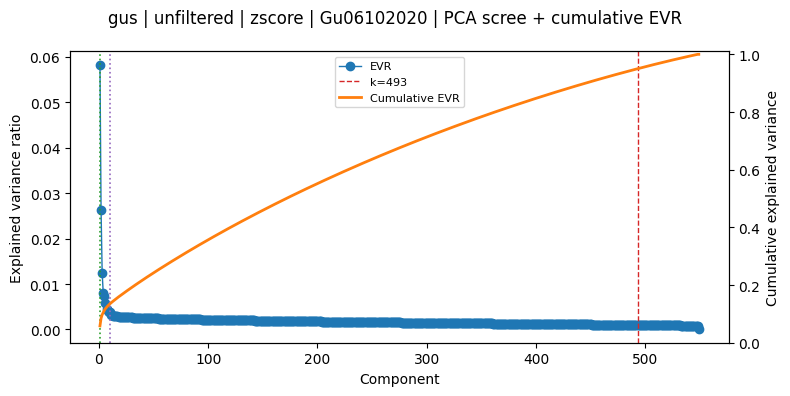

In [6]:
SHOW_EVR_INLINE = True

if SHOW_EVR_INLINE:
    for subject in subjects:
        disp = display_session_by_subject.get(subject)
        if disp is None:
            continue
        key = (str(subject), str(disp["session_id"]))
        if key not in pca_results:
            continue

        r = pca_results[key]
        fig = plot_scree_cumulative(
            r["evr"],
            r["evr_cum"],
            k_chosen=int(r["k_keep"]),
            title=f"{subject} | {data_condition} | {data_variant} | {r['session_id']} | PCA scree + cumulative EVR",
        )

        # Add reference lines for k_drop=1 and max tested k_drop when valid.
        ax = fig.axes[0]
        valid_k = list(r["valid_k_drop"])
        if 1 in valid_k:
            ax.axvline(1, color="tab:green", ls=":", lw=1.2)
        if len(valid_k) > 0:
            ax.axvline(max(valid_k), color="tab:purple", ls=":", lw=1.2)

        _save_fig(
            fig,
            f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(r['session_id'])}_pca_scree_evr.png",
        )
        plt.show()

# Backward-compatible aliases for downstream cells (first subject display session).
first_subject = next((s for s in subjects if s in display_session_by_subject), None)
if first_subject is None:
    raise RuntimeError("No display session found to populate Section 3 output aliases.")

display_key = (str(first_subject), str(display_session_by_subject[first_subject]["session_id"]))
if display_key not in pca_results:
    raise RuntimeError(f"Display key missing in pca_results: {display_key}")

_display_result = pca_results[display_key]

pca = _display_result["pca_model"]
scores = _display_result["scores"]
components = _display_result["components"]
explained_var_ratio = _display_result["evr"]
mean_ = _display_result["mean_"]
spatial_maps = _display_result["components_hw"]

# Useful multi-session mappings for later sections.
k_keep_by_session = {k: v["k_keep"] for k, v in pca_results.items()}
valid_k_drop_by_session = {k: list(v["valid_k_drop"]) for k, v in pca_results.items()}

section3_outputs = {
    "pca_results": pca_results,
    "pca_summary_df": pca_summary_df,
    "display_key": display_key,
    "k_keep_by_session": k_keep_by_session,
    "valid_k_drop_by_session": valid_k_drop_by_session,
    "pca": pca,
    "scores": scores,
    "components": components,
    "explained_var_ratio": explained_var_ratio,
    "mean_": mean_,
    "spatial_maps": spatial_maps,
}


---
### PC Identity (Dropped PCs)
Plot only the PCs in pcs_to_inspect for each subject display session: spatial loadings and score traces.
#### Section 4A: Spatial loading maps for PCs being dropped

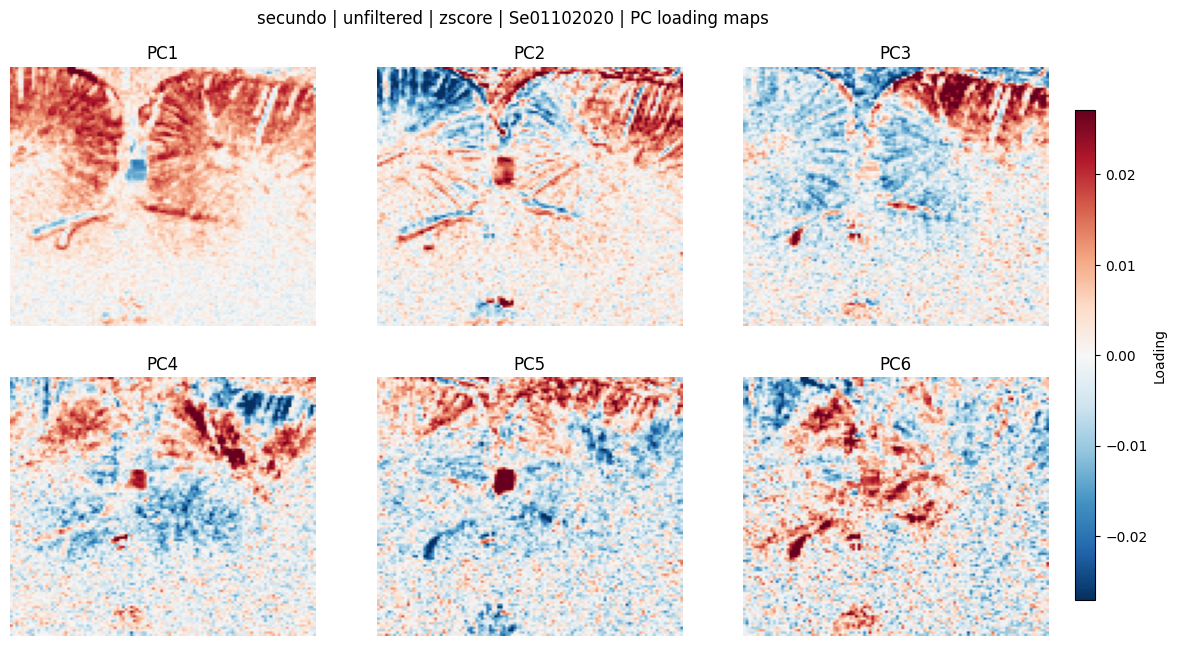

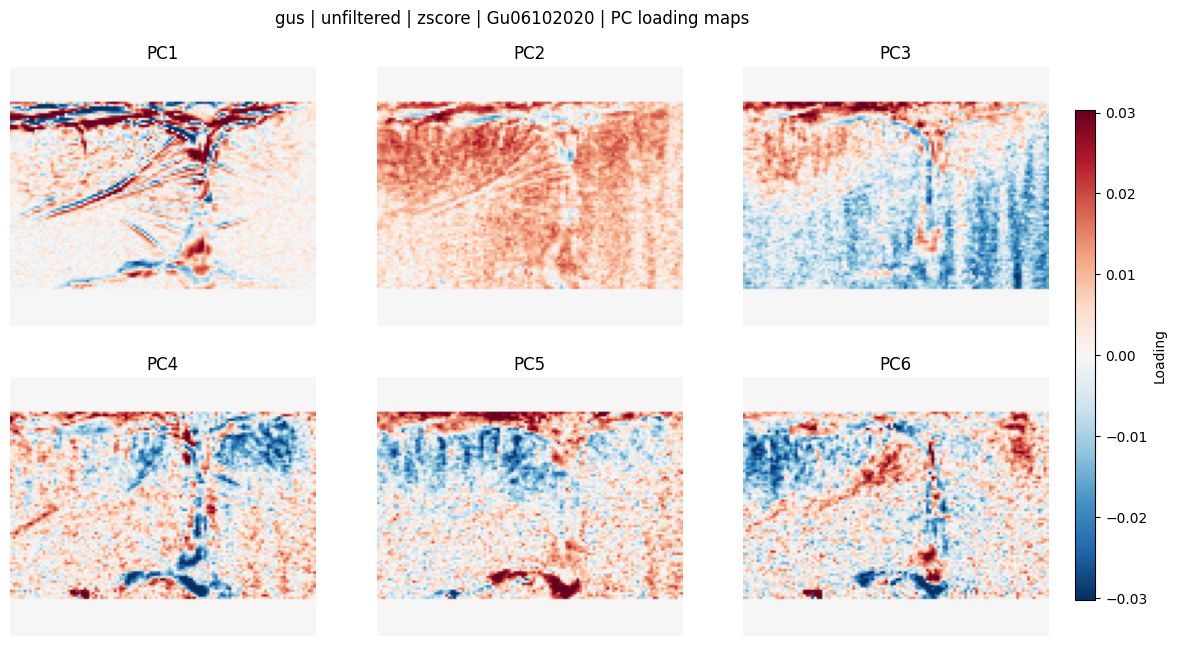

In [7]:
LOADING_ABS_PCTL = 99.0
MAX_COLS = 3
CBAR_RECT = [0.92, 0.16, 0.015, 0.68]  # [left, bottom, width, height] in figure coords

for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue

    key = (str(subject), str(disp["session_id"]))
    if key not in pca_results:
        continue

    r = pca_results[key]
    pcs = list(r.get("pcs_to_inspect", []))
    if len(pcs) == 0:
        continue

    maps = np.asarray(r["components_hw"], dtype=np.float32)
    selected_maps = np.stack([maps[pc - 1] for pc in pcs], axis=0)

    finite = selected_maps[np.isfinite(selected_maps)]
    vmax = float(np.percentile(np.abs(finite), LOADING_ABS_PCTL)) if finite.size else 1.0
    vmax = max(vmax, 1e-8)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    n = len(pcs)
    ncols = int(min(MAX_COLS, n))
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols + 0.8, 3.6 * nrows), squeeze=False)
    fig.subplots_adjust(right=0.9, top=0.90)  # reserve space on right for colorbar and top for grand title
    axes_flat = axes.ravel()

    for i, pc in enumerate(pcs):
        ax = axes_flat[i]
        im = ax.imshow(selected_maps[i], cmap="RdBu_r", norm=norm, aspect="auto")
        ax.set_title(f"PC{pc}")
        ax.axis("off")

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    cax = fig.add_axes(CBAR_RECT)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Loading")
    fig.suptitle(f"{subject} | {data_condition} | {data_variant} | {r['session_id']} | PC loading maps")

    _save_fig(
        fig,
        f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(r['session_id'])}_pc_loading_maps.png",
    )
    plt.show()

#### Section 4B: PC score traces for the same PCs

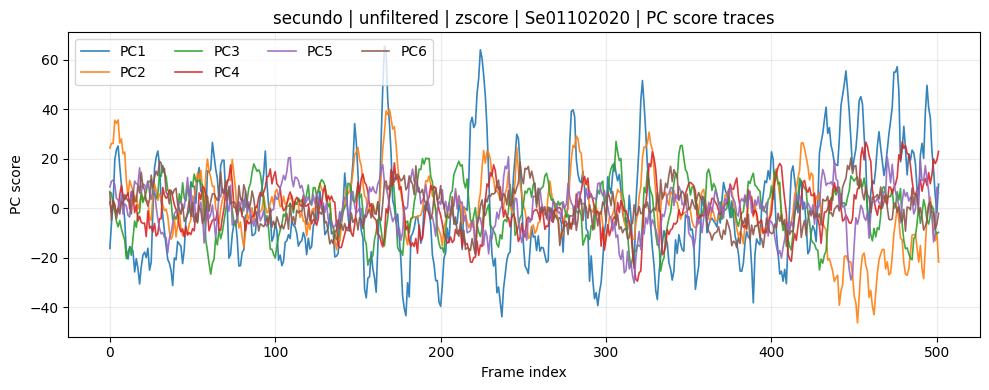

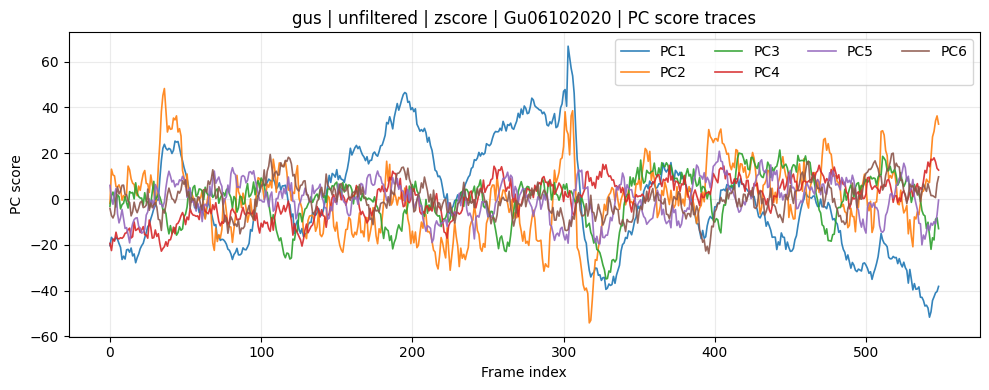

In [8]:
SCORE_TRACE_ALPHA = 0.9
SCORE_TRACE_LW = 1.2

for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue

    key = (str(subject), str(disp["session_id"]))
    if key not in pca_results:
        continue

    r = pca_results[key]
    pcs = list(r.get("pcs_to_inspect", []))
    if len(pcs) == 0:
        continue

    scores_arr = np.asarray(r["scores"], dtype=np.float32)
    t = np.arange(scores_arr.shape[0])

    fig, ax = plt.subplots(figsize=(10, 4))
    for pc in pcs:
        ax.plot(
            t,
            scores_arr[:, pc - 1],
            lw=SCORE_TRACE_LW,
            alpha=SCORE_TRACE_ALPHA,
            label=f"PC{pc}",
        )

    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {r['session_id']} | PC score traces")
    ax.set_xlabel("Frame index")
    ax.set_ylabel("PC score")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", ncol=min(4, len(pcs)))
    fig.tight_layout()

    _save_fig(
        fig,
        f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(r['session_id'])}_pc_score_traces.png",
    )
    plt.show()


---
## Effect on ACF curve
This section will look at the effect of dropping pcs on the acf curve. It will plot ACF curves vs lag for: raw (or full recon) + each drop condition, for each drop condition (much easier to interpret than stacked lines), Summary metrics vs k_drop (AUC of ACF over lag window; half-life)

In [9]:
# Section 5 (compute): Reconstruction + ACF core analysis
acf_cfg = main_params["acf"]
sanity_cfg = main_params.get("sanity", {})

ACF_MAX_LAG = int(acf_cfg.get("max_lag", 500))
ACF_AUC_L = int(acf_cfg.get("auc_lag_window", 150))
ACF_HALF_THR = float(acf_cfg.get("half_life_threshold", 0.2))
K_REF = int(sanity_cfg.get("k_drop_ref", 1))


def _global_signal_from_X(X):
    x = np.asarray(X, dtype=np.float64)
    if x.ndim == 3:
        g = np.nanmean(x, axis=(1, 2)).astype(np.float64)
    elif x.ndim == 2:
        g = np.nanmean(x, axis=1).astype(np.float64)
    else:
        raise ValueError(f"Expected [T,H,W] or [T,V], got {x.shape}")

    g = g[np.isfinite(g)]
    if g.size < 2:
        return None

    g = g - np.mean(g)
    if (not np.isfinite(np.var(g))) or (np.var(g) < 1e-12):
        return None
    return g


def _standardized_acf(x, max_lag):
    x = np.asarray(x, dtype=np.float64)
    if x.size < 2:
        return None, None

    corr_full = np.correlate(x, x, mode="full")
    mid = corr_full.size // 2
    corr = corr_full[mid:]

    if corr[0] == 0 or (not np.isfinite(corr[0])):
        return None, None

    L = int(min(int(max_lag), x.size - 1))
    lags = np.arange(L + 1, dtype=np.int32)
    acf_vals = corr[: L + 1] / corr[0]
    return lags, acf_vals


def _acf_auc(acf_vals, L):
    a = np.asarray(acf_vals, dtype=np.float64).reshape(-1)
    if a.size <= 1:
        return np.nan
    L_eff = int(min(int(L), a.size - 1))
    if L_eff < 1:
        return np.nan
    return float(np.sum(a[1 : L_eff + 1]))


def _first_crossing(acf_vals, thr):
    a = np.asarray(acf_vals, dtype=np.float64).reshape(-1)
    if a.size <= 1:
        return np.nan
    idx = np.where(a[1:] <= float(thr))[0]
    if idx.size == 0:
        return np.nan
    return float(idx[0] + 1)


acf_by_condition = {}
delta_acf_by_condition = {}
recons_by_condition = {}
summary_rows = []

for key, r in pca_results.items():
    subject, session_id = key

    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue

    frames_raw = np.asarray(disp["frames"], dtype=np.float64)
    T, H, W = [int(v) for v in frames_raw.shape]

    X_raw = frames_raw.reshape(T, H * W)
    base_sig = _global_signal_from_X(X_raw)
    lags_base, acf_base = _standardized_acf(base_sig, ACF_MAX_LAG)
    if acf_base is None:
        print(f"[skip] baseline ACF failed for {subject}/{session_id}")
        continue

    base_cond = "baseline"
    acf_by_condition[(subject, session_id, base_cond)] = {
        "lags": np.asarray(lags_base, dtype=np.int32),
        "acf": np.asarray(acf_base, dtype=np.float64),
    }
    recons_by_condition[(subject, session_id, base_cond)] = {
        "global_ts": np.asarray(base_sig, dtype=np.float32),
        "frames": frames_raw.astype(np.float32),
    }

    summary_rows.append(
        {
            "subject": str(subject),
            "session_id": str(session_id),
            "k_drop": -1,
            "condition": base_cond,
            "acf_auc": _acf_auc(acf_base, ACF_AUC_L),
            "acf_half_life": _first_crossing(acf_base, ACF_HALF_THR),
        }
    )

    Z = np.asarray(r["scores"], dtype=np.float64)       # [T, K]
    C = np.asarray(r["components"], dtype=np.float64)   # [K, V]
    mu = np.asarray(r["mean_"], dtype=np.float64)       # [V]
    feat_mu = np.asarray(r["feature_mu"], dtype=np.float64)  # [1, V]
    feat_sd = np.asarray(r["feature_sd"], dtype=np.float64)  # [1, V]

    valid_k = list(r.get("valid_k_drop", []))
    if len(valid_k) == 0:
        print(f"[warn] no valid k_drop for {subject}/{session_id}")
        continue

    k_ref_eff = K_REF if K_REF in valid_k else (valid_k[1] if len(valid_k) > 1 else valid_k[0])

    for k in valid_k:
        Z_drop = Z.copy()
        if int(k) > 0:
            Z_drop[:, : int(k)] = 0.0

        X_fit_recon = Z_drop @ C + mu[None, :]
        if bool(r.get("standardize_features", False)):
            X_recon = X_fit_recon * feat_sd + feat_mu
        else:
            X_recon = X_fit_recon

        sig_k = _global_signal_from_X(X_recon)
        lags_k, acf_k = _standardized_acf(sig_k, ACF_MAX_LAG)
        if acf_k is None:
            continue

        L = int(min(lags_base[-1], lags_k[-1]))
        lags_u = np.asarray(lags_k[: L + 1], dtype=np.int32)
        acf_u = np.asarray(acf_k[: L + 1], dtype=np.float64)
        acf_base_u = np.asarray(acf_base[: L + 1], dtype=np.float64)
        delta_u = acf_u - acf_base_u

        cond_name = f"k_drop_{int(k)}"
        acf_by_condition[(subject, session_id, cond_name)] = {
            "lags": lags_u,
            "acf": acf_u,
        }
        delta_acf_by_condition[(subject, session_id, int(k))] = {
            "lags": lags_u,
            "delta_acf": delta_u,
        }

        recon_pack = {
            "global_ts": np.asarray(sig_k, dtype=np.float32),
        }
        if int(k) in {0, int(k_ref_eff)}:
            recon_pack["frames"] = X_recon.reshape(T, H, W).astype(np.float32)
        recons_by_condition[(subject, session_id, cond_name)] = recon_pack

        summary_rows.append(
            {
                "subject": str(subject),
                "session_id": str(session_id),
                "k_drop": int(k),
                "condition": cond_name,
                "acf_auc": _acf_auc(acf_u, ACF_AUC_L),
                "acf_half_life": _first_crossing(acf_u, ACF_HALF_THR),
            }
        )

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values(["subject", "session_id", "k_drop"], kind="stable").reset_index(drop=True)

display(summary_df.head(20))
print(f"Computed ACF entries: {len(acf_by_condition)}")
print(f"Computed delta ACF entries: {len(delta_acf_by_condition)}")
print(f"Reconstruction packs: {len(recons_by_condition)}")


,subject,session_id,k_drop,condition,acf_auc,acf_half_life
0,gus,Gu06102020,-1,baseline,1.030582,11.0
1,gus,Gu06102020,0,k_drop_0,1.030582,11.0
2,gus,Gu06102020,1,k_drop_1,13.011082,11.0
3,gus,Gu06102020,2,k_drop_2,8.393047,12.0
4,gus,Gu06102020,5,k_drop_5,-0.502700,4.0
5,gus,Gu06102020,10,k_drop_10,0.013747,3.0
6,secundo,Se01102020,-1,baseline,2.330090,6.0
7,secundo,Se01102020,0,k_drop_0,2.330090,6.0
8,secundo,Se01102020,1,k_drop_1,3.148160,9.0
9,secundo,Se01102020,2,k_drop_2,-0.531390,3.0


Computed ACF entries: 12
Computed delta ACF entries: 10
Reconstruction packs: 12


### Bootstrap uncertainty
Compute paired block-bootstrap CIs for ACF, ΔACF, and summary metrics.


In [10]:
# Section 6 (compute): Bootstrap uncertainty
boot_cfg = main_params.get("bootstrap", {})
BOOT_ENABLED = bool(boot_cfg.get("enabled", True))
BOOT_N = int(boot_cfg.get("n_boot", 300))
BOOT_CI = float(boot_cfg.get("ci", 95.0))
BOOT_BLOCK = int(boot_cfg.get("block_len", 32))
BOOT_MIN_BLOCK = int(boot_cfg.get("min_block_len", 8))
BOOT_SEED = int(boot_cfg.get("seed", 42))


def _block_boot_idx(T, block_len, rng):
    if T <= 0:
        return np.array([], dtype=np.int64)
    b = max(1, int(block_len))
    out = []
    while len(out) < T:
        s = int(rng.integers(0, T))
        blk = ((np.arange(b, dtype=np.int64) + s) % T).tolist()
        out.extend(blk)
    return np.asarray(out[:T], dtype=np.int64)


bootstrap_results = {}

if not BOOT_ENABLED:
    print("Bootstrap disabled in config.")
else:
    alpha = (100.0 - BOOT_CI) / 2.0

    for subject in subjects:
        disp = display_session_by_subject.get(subject)
        if disp is None:
            continue
        session_id = str(disp["session_id"])

        base_key = (str(subject), str(session_id), "baseline")
        if base_key not in acf_by_condition:
            continue

        # Collect available conditions and global signals
        cond_keys = [
            k for k in acf_by_condition.keys()
            if k[0] == str(subject) and k[1] == str(session_id)
        ]
        cond_names = sorted([str(k[2]) for k in cond_keys], key=lambda c: (-1 if c == "baseline" else int(c.split("_")[-1])))

        ts_by_cond = {}
        for cond in cond_names:
            rk = (str(subject), str(session_id), cond)
            if rk not in recons_by_condition:
                continue
            ts = np.asarray(recons_by_condition[rk].get("global_ts", []), dtype=np.float64).reshape(-1)
            ts = ts[np.isfinite(ts)]
            if ts.size >= 3:
                ts_by_cond[cond] = ts

        if "baseline" not in ts_by_cond:
            continue

        Tmin = int(min(len(v) for v in ts_by_cond.values()))
        if Tmin < 8:
            print(f"[skip bootstrap] {subject}/{session_id}: too short T={Tmin}")
            continue

        b_eff = int(min(max(BOOT_MIN_BLOCK, 1), max(1, BOOT_BLOCK), Tmin))

        obs_acf = {}
        for cond in cond_names:
            if cond not in ts_by_cond:
                continue
            l, a = _standardized_acf(ts_by_cond[cond] - np.mean(ts_by_cond[cond]), ACF_MAX_LAG)
            if a is None:
                continue
            obs_acf[cond] = (np.asarray(l, dtype=np.int32), np.asarray(a, dtype=np.float64))

        if "baseline" not in obs_acf:
            continue

        rng = np.random.default_rng(BOOT_SEED + abs(hash((subject, session_id))) % (10**6))

        acf_boot = {cond: [] for cond in obs_acf.keys()}
        delta_boot = {}
        metric_boot = {}

        k_drop_names = [c for c in obs_acf.keys() if c.startswith("k_drop_")]
        for c in k_drop_names:
            k = int(c.split("_")[-1])
            delta_boot[k] = []
            metric_boot[k] = {"acf_auc": [], "acf_half_life": []}

        for _ in range(BOOT_N):
            idx = _block_boot_idx(Tmin, b_eff, rng)

            base_s = ts_by_cond["baseline"][:Tmin][idx]
            _, base_a = _standardized_acf(base_s - np.mean(base_s), ACF_MAX_LAG)
            if base_a is None:
                continue

            for cond in list(obs_acf.keys()):
                s = ts_by_cond[cond][:Tmin][idx]
                _, a = _standardized_acf(s - np.mean(s), ACF_MAX_LAG)
                if a is None:
                    continue

                l_obs, a_obs = obs_acf[cond]
                L = int(min(len(a_obs), len(a)) - 1)
                if L < 1:
                    continue
                a_u = np.asarray(a[: L + 1], dtype=np.float64)
                acf_boot[cond].append(a_u)

                if cond.startswith("k_drop_"):
                    k = int(cond.split("_")[-1])
                    Ld = int(min(L, len(base_a) - 1, len(obs_acf["baseline"][1]) - 1))
                    if Ld < 1:
                        continue
                    d_u = np.asarray(a[: Ld + 1], dtype=np.float64) - np.asarray(base_a[: Ld + 1], dtype=np.float64)
                    delta_boot[k].append(d_u)
                    metric_boot[k]["acf_auc"].append(_acf_auc(a[: L + 1], ACF_AUC_L))
                    metric_boot[k]["acf_half_life"].append(_first_crossing(a[: L + 1], ACF_HALF_THR))

        acf_ci_by_condition = {}
        for cond, arr_list in acf_boot.items():
            if len(arr_list) == 0:
                continue
            min_len = int(min(len(a) for a in arr_list))
            A = np.stack([a[:min_len] for a in arr_list], axis=0)
            lags = np.arange(min_len, dtype=np.int32)
            acf_ci_by_condition[cond] = {
                "lags": lags,
                "lo": np.nanpercentile(A, alpha, axis=0),
                "hi": np.nanpercentile(A, 100.0 - alpha, axis=0),
                "mean": np.nanmean(A, axis=0),
                "n_boot_effective": int(A.shape[0]),
            }

        delta_ci_by_kdrop = {}
        for k, arr_list in delta_boot.items():
            if len(arr_list) == 0:
                continue
            min_len = int(min(len(a) for a in arr_list))
            D = np.stack([a[:min_len] for a in arr_list], axis=0)
            lags = np.arange(min_len, dtype=np.int32)
            delta_ci_by_kdrop[int(k)] = {
                "lags": lags,
                "lo": np.nanpercentile(D, alpha, axis=0),
                "hi": np.nanpercentile(D, 100.0 - alpha, axis=0),
                "mean": np.nanmean(D, axis=0),
                "n_boot_effective": int(D.shape[0]),
            }

        metric_ci_by_kdrop = {}
        for k, m in metric_boot.items():
            metric_ci_by_kdrop[int(k)] = {}
            for metric_name, vals in m.items():
                v = np.asarray(vals, dtype=np.float64)
                v = v[np.isfinite(v)]
                if v.size == 0:
                    continue
                metric_ci_by_kdrop[int(k)][metric_name] = {
                    "lo": float(np.nanpercentile(v, alpha)),
                    "hi": float(np.nanpercentile(v, 100.0 - alpha)),
                    "mean": float(np.nanmean(v)),
                    "n_boot_effective": int(v.size),
                }

        bootstrap_results[(str(subject), str(session_id))] = {
            "config": {
                "enabled": BOOT_ENABLED,
                "n_boot": BOOT_N,
                "ci": BOOT_CI,
                "block_len": b_eff,
                "seed": BOOT_SEED,
            },
            "acf_ci_by_condition": acf_ci_by_condition,
            "delta_ci_by_kdrop": delta_ci_by_kdrop,
            "metric_ci_by_kdrop": metric_ci_by_kdrop,
        }

print(f"Bootstrap packs: {len(bootstrap_results)}")


Bootstrap packs: 2


#### ACF curves vs lag (baseline + k_drop)

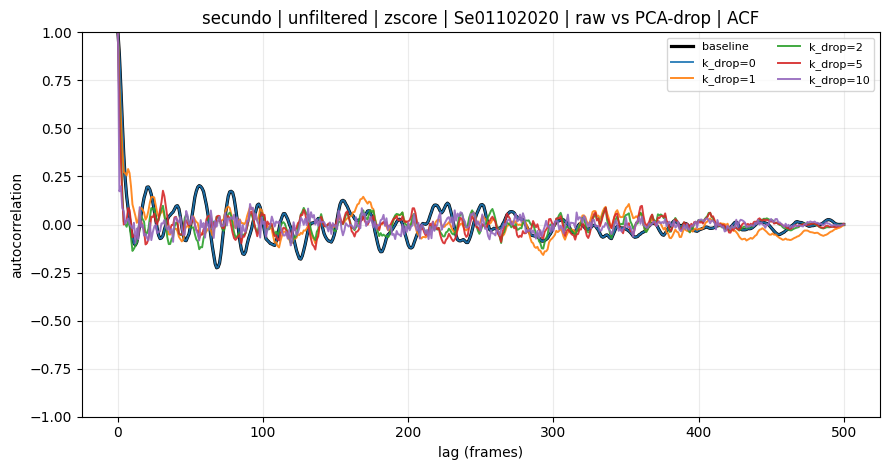

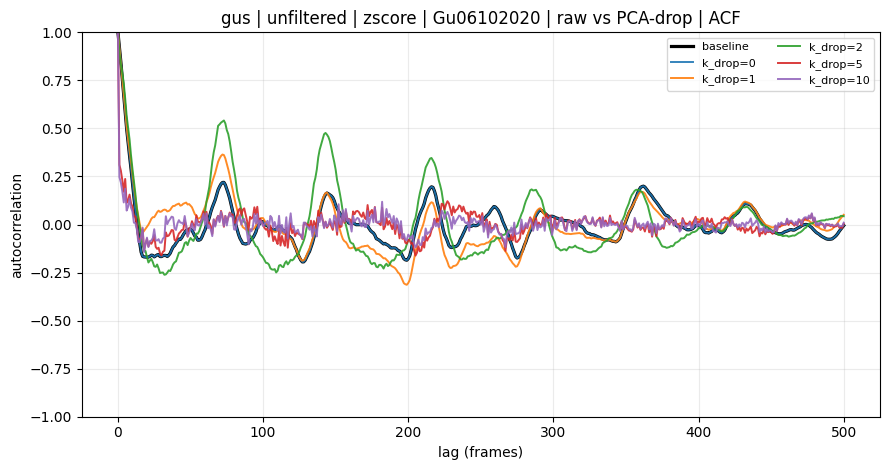

In [11]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])

    base_key = (str(subject), str(session_id), "baseline")
    if base_key not in acf_by_condition:
        continue

    boot_pack = bootstrap_results.get((str(subject), str(session_id)), {})
    acf_ci = boot_pack.get("acf_ci_by_condition", {})

    base = acf_by_condition[base_key]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(base["lags"], base["acf"], color="black", lw=2.3, label="baseline")
    if "baseline" in acf_ci:
        ci = acf_ci["baseline"]
        L = int(min(len(base["lags"]), len(ci["lo"])))

    cond_keys = [
        k for k in acf_by_condition.keys()
        if k[0] == str(subject) and k[1] == str(session_id) and str(k[2]).startswith("k_drop_")
    ]
    cond_keys = sorted(cond_keys, key=lambda k: int(str(k[2]).split("_")[-1]))

    for ck in cond_keys:
        cond_name = str(ck[2])
        k_drop = int(cond_name.split("_")[-1])
        d = acf_by_condition[ck]
        ax.plot(d["lags"], d["acf"], lw=1.4, alpha=0.9, label=f"k_drop={k_drop}")
        if cond_name in acf_ci:
            ci = acf_ci[cond_name]
            L = int(min(len(d["lags"]), len(ci["lo"])))

    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | raw vs PCA-drop | ACF")
    ax.set_xlabel("lag (frames)")
    ax.set_ylabel("autocorrelation")
    ax.set_ylim(-1.0, 1.0)
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8, ncol=2)
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_acf_curves.png")
    plt.show()


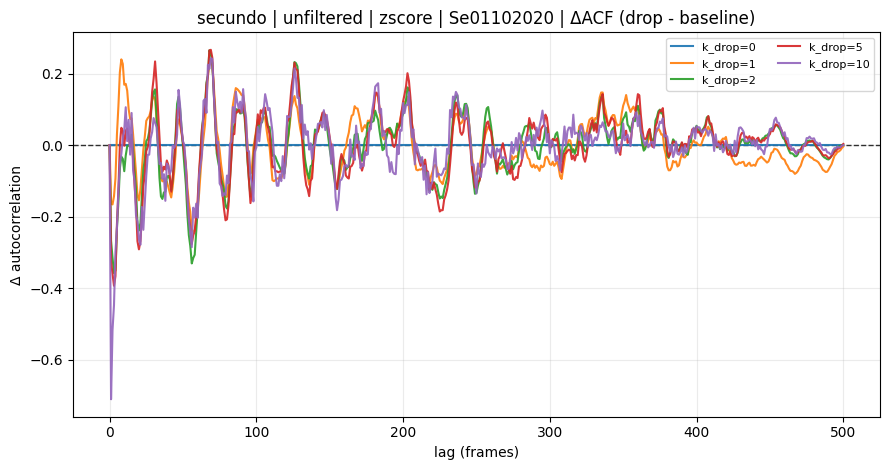

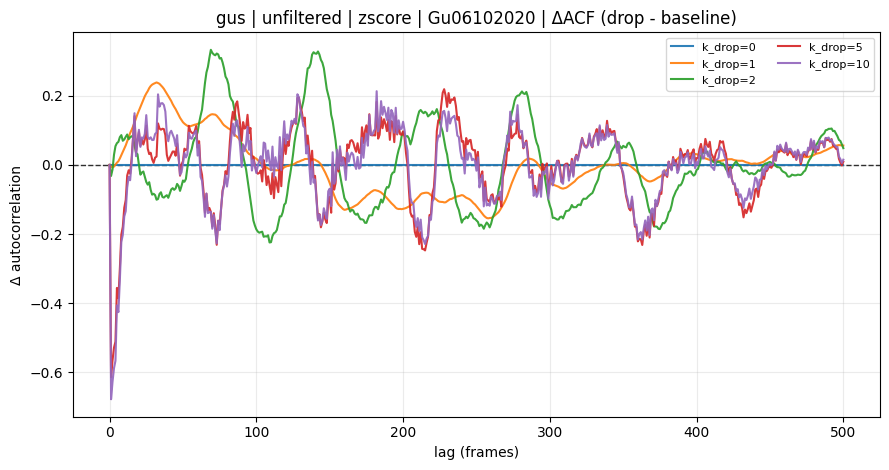

In [12]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])

    keys = [k for k in delta_acf_by_condition.keys() if k[0] == str(subject) and k[1] == str(session_id)]
    keys = sorted(keys, key=lambda k: int(k[2]))
    if len(keys) == 0:
        continue

    boot_pack = bootstrap_results.get((str(subject), str(session_id)), {})
    delta_ci = boot_pack.get("delta_ci_by_kdrop", {})

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.axhline(0.0, color="black", lw=1.0, ls="--", alpha=0.8)

    for dk in keys:
        k_drop = int(dk[2])
        d = delta_acf_by_condition[dk]
        ax.plot(d["lags"], d["delta_acf"], lw=1.5, alpha=0.92, label=f"k_drop={k_drop}")
        if k_drop in delta_ci:
            ci = delta_ci[k_drop]
            L = int(min(len(d["lags"]), len(ci["lo"])))

    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | ΔACF (drop - baseline)")
    ax.set_xlabel("lag (frames)")
    ax.set_ylabel("Δ autocorrelation")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8, ncol=2)
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_delta_acf_curves.png")
    plt.show()


#### ACF AUC vs k_drop

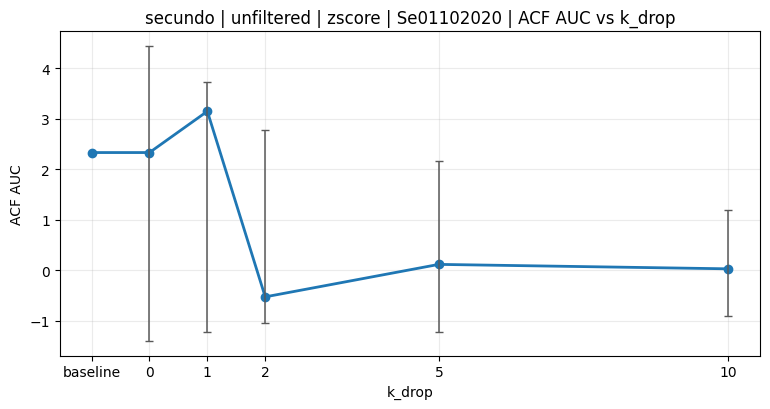

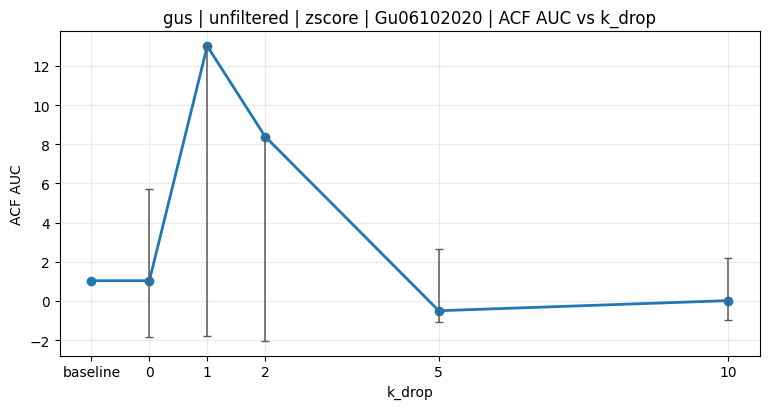

In [13]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])

    sdf = summary_df[(summary_df["subject"] == str(subject)) & (summary_df["session_id"] == str(session_id))].copy()
    if sdf.empty:
        continue

    sdf = sdf.sort_values("k_drop", kind="stable")
    x = sdf["k_drop"].to_numpy(dtype=float)
    y = sdf["acf_auc"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.8, 4.2))
    ax.plot(x, y, marker="o", lw=2.0)

    boot_pack = bootstrap_results.get((str(subject), str(session_id)), {})
    metric_ci = boot_pack.get("metric_ci_by_kdrop", {})
    x_ci, y_ci, lo_ci, hi_ci = [], [], [], []
    for xv, yv in zip(x, y):
        k = int(xv)
        if k < 0 or k not in metric_ci or "acf_auc" not in metric_ci[k]:
            continue
        ci = metric_ci[k]["acf_auc"]
        x_ci.append(float(xv)); y_ci.append(float(yv)); lo_ci.append(float(ci["lo"])); hi_ci.append(float(ci["hi"]))
    if len(x_ci) > 0:
        x_ci_arr = np.asarray(x_ci, dtype=float)
        y_ci_arr = np.asarray(y_ci, dtype=float)
        lo_arr = np.asarray(lo_ci, dtype=float)
        hi_arr = np.asarray(hi_ci, dtype=float)
        lo_arr, hi_arr = np.minimum(lo_arr, hi_arr), np.maximum(lo_arr, hi_arr)
        valid = np.isfinite(x_ci_arr) & np.isfinite(y_ci_arr) & np.isfinite(lo_arr) & np.isfinite(hi_arr)
        if np.any(valid):
            x_ci_arr = x_ci_arr[valid]
            y_ci_arr = y_ci_arr[valid]
            lo_arr = lo_arr[valid]
            hi_arr = hi_arr[valid]
            yerr = np.vstack([
                np.clip(y_ci_arr - lo_arr, 0.0, None),
                np.clip(hi_arr - y_ci_arr, 0.0, None),
            ])
            ax.errorbar(x_ci_arr, y_ci_arr, yerr=yerr, fmt='none', ecolor='0.35', capsize=3, lw=1.1)

    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | ACF AUC vs k_drop")
    ax.set_xlabel("k_drop")
    ax.set_ylabel("ACF AUC")
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(["baseline" if int(v) == -1 else str(int(v)) for v in x], rotation=0)
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_acf_auc_vs_kdrop.png")
    plt.show()


#### ACF half-life vs k_drop

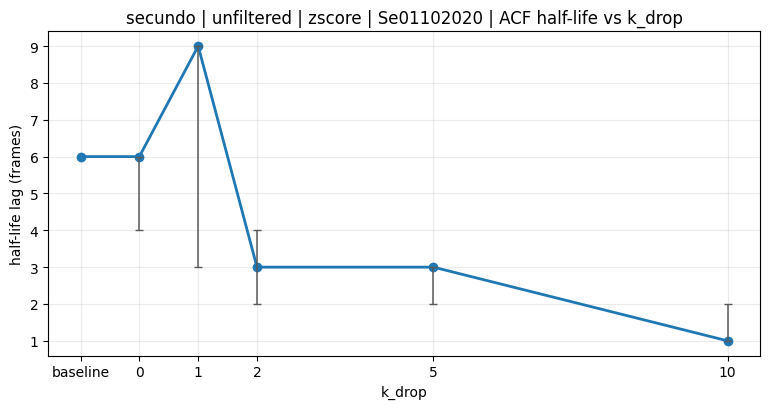

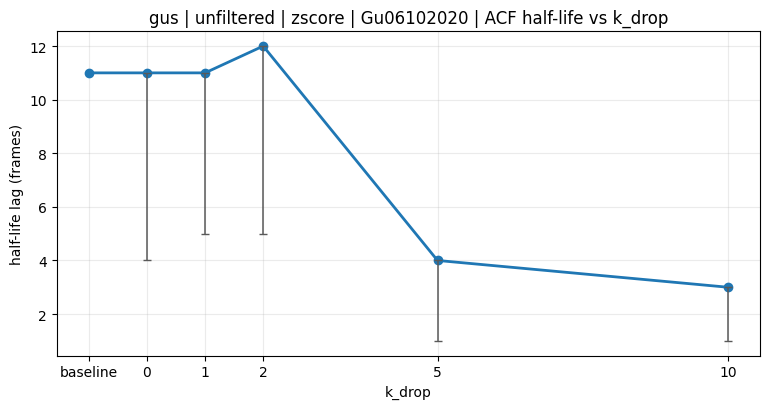

In [14]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])

    sdf = summary_df[(summary_df["subject"] == str(subject)) & (summary_df["session_id"] == str(session_id))].copy()
    if sdf.empty:
        continue

    sdf = sdf.sort_values("k_drop", kind="stable")
    x = sdf["k_drop"].to_numpy(dtype=float)
    y = sdf["acf_half_life"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.8, 4.2))
    ax.plot(x, y, marker="o", lw=2.0)

    boot_pack = bootstrap_results.get((str(subject), str(session_id)), {})
    metric_ci = boot_pack.get("metric_ci_by_kdrop", {})
    x_ci, y_ci, lo_ci, hi_ci = [], [], [], []
    for xv, yv in zip(x, y):
        k = int(xv)
        if k < 0 or k not in metric_ci or "acf_half_life" not in metric_ci[k]:
            continue
        ci = metric_ci[k]["acf_half_life"]
        x_ci.append(float(xv)); y_ci.append(float(yv)); lo_ci.append(float(ci["lo"])); hi_ci.append(float(ci["hi"]))
    if len(x_ci) > 0:
        x_ci_arr = np.asarray(x_ci, dtype=float)
        y_ci_arr = np.asarray(y_ci, dtype=float)
        lo_arr = np.asarray(lo_ci, dtype=float)
        hi_arr = np.asarray(hi_ci, dtype=float)
        lo_arr, hi_arr = np.minimum(lo_arr, hi_arr), np.maximum(lo_arr, hi_arr)
        valid = np.isfinite(x_ci_arr) & np.isfinite(y_ci_arr) & np.isfinite(lo_arr) & np.isfinite(hi_arr)
        if np.any(valid):
            x_ci_arr = x_ci_arr[valid]
            y_ci_arr = y_ci_arr[valid]
            lo_arr = lo_arr[valid]
            hi_arr = hi_arr[valid]
            yerr = np.vstack([
                np.clip(y_ci_arr - lo_arr, 0.0, None),
                np.clip(hi_arr - y_ci_arr, 0.0, None),
            ])
            ax.errorbar(x_ci_arr, y_ci_arr, yerr=yerr, fmt='none', ecolor='0.35', capsize=3, lw=1.1)

    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | ACF half-life vs k_drop")
    ax.set_xlabel("k_drop")
    ax.set_ylabel("half-life lag (frames)")
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(["baseline" if int(v) == -1 else str(int(v)) for v in x], rotation=0)
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_acf_half_life_vs_kdrop.png")
    plt.show()


### Section Outputs
store outputs in variables for later use: acf_by_condition, delta_acf_by_condition, summary_df

In [15]:
# Section 5 outputs
section5_outputs = {
    "acf_by_condition": acf_by_condition,
    "delta_acf_by_condition": delta_acf_by_condition,
    "summary_df": summary_df,
    "recons_by_condition": recons_by_condition,
}


---
## PCA Robustness checks
this section will check the pca reconstruction. it will plot raw vs recon overlay (and residual) for a representative voxel/ROI/time window, uncertainty on ACF  (bootstrap across windows/sessions/voxels/ROIs; show CI band), Frequency-domain check (PSD) pre/post drop (optional but often helpful). It will also compare the reconstructions of the different conditons (same plot just different colour traces per condition.)

In [16]:
sanity_cfg = main_params.get("sanity", {})
PSD_ENABLED = bool(sanity_cfg.get("psd_enabled", True))
PSD_FS = float(sanity_cfg.get("psd_fs_hz", 1.0))
PSD_NPERSEG_MAX = int(sanity_cfg.get("psd_nperseg_max", 256))
PSD_FMIN = float(sanity_cfg.get("psd_fmin", 0.01))
PSD_FMAX = float(sanity_cfg.get("psd_fmax", 0.5))
K_REF = int(sanity_cfg.get("k_drop_ref", 1))

residuals_by_condition = {}
psd_by_condition = {}

for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])

    base_key = (str(subject), str(session_id), "baseline")
    if base_key not in recons_by_condition:
        continue

    # Pick reference k_drop condition for sanity overlays/residuals
    cand = [k for k in recons_by_condition.keys() if k[0] == str(subject) and k[1] == str(session_id) and str(k[2]).startswith("k_drop_")]
    if len(cand) == 0:
        continue
    cand_sorted = sorted(cand, key=lambda k: int(str(k[2]).split("_")[-1]))
    ref_key = next((k for k in cand_sorted if int(str(k[2]).split("_")[-1]) == K_REF), cand_sorted[0])
    k_ref_used = int(str(ref_key[2]).split("_")[-1])

    raw_ts = np.asarray(recons_by_condition[base_key]["global_ts"], dtype=np.float64)
    recon_ts = np.asarray(recons_by_condition[ref_key]["global_ts"], dtype=np.float64)
    Tm = int(min(len(raw_ts), len(recon_ts)))
    raw_ts = raw_ts[:Tm]
    recon_ts = recon_ts[:Tm]
    resid_ts = raw_ts - recon_ts

    pack = {
        "subject": str(subject),
        "session_id": str(session_id),
        "k_drop_ref": int(k_ref_used),
        "raw_ts": raw_ts.astype(np.float32),
        "recon_ts": recon_ts.astype(np.float32),
        "residual_ts": resid_ts.astype(np.float32),
    }

    raw_frames = np.asarray(disp["frames"], dtype=np.float32)
    if "frames" in recons_by_condition.get(ref_key, {}):
        recon_frames = np.asarray(recons_by_condition[ref_key]["frames"], dtype=np.float32)
        Tmf = int(min(raw_frames.shape[0], recon_frames.shape[0]))
        raw_frames = raw_frames[:Tmf]
        recon_frames = recon_frames[:Tmf]
        pack["raw_frames"] = raw_frames
        pack["recon_frames"] = recon_frames
        pack["residual_frames"] = raw_frames - recon_frames

    residuals_by_condition[(str(subject), str(session_id))] = pack

    if PSD_ENABLED and Tm >= 8:
        nperseg = int(min(PSD_NPERSEG_MAX, Tm))
        f_raw, p_raw = welch(raw_ts, fs=PSD_FS, nperseg=nperseg, detrend="constant")
        f_rec, p_rec = welch(recon_ts, fs=PSD_FS, nperseg=nperseg, detrend="constant")
        f_res, p_res = welch(resid_ts, fs=PSD_FS, nperseg=nperseg, detrend="constant")

        psd_by_condition[(str(subject), str(session_id))] = {
            "k_drop_ref": int(k_ref_used),
            "f_raw": f_raw, "p_raw": p_raw,
            "f_recon": f_rec, "p_recon": p_rec,
            "f_residual": f_res, "p_residual": p_res,
            "fmin": PSD_FMIN, "fmax": PSD_FMAX,
        }

print(f"Residual packs: {len(residuals_by_condition)}")
print(f"PSD packs: {len(psd_by_condition)}")


Residual packs: 2
PSD packs: 2


#### raw vs recon overlay (global signal)

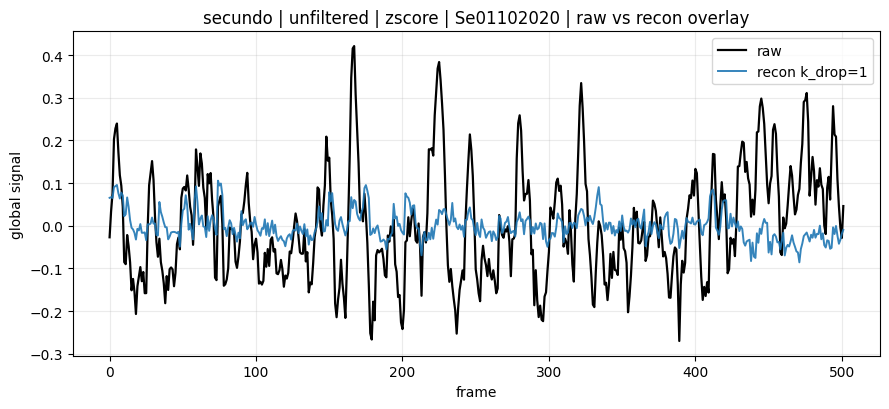

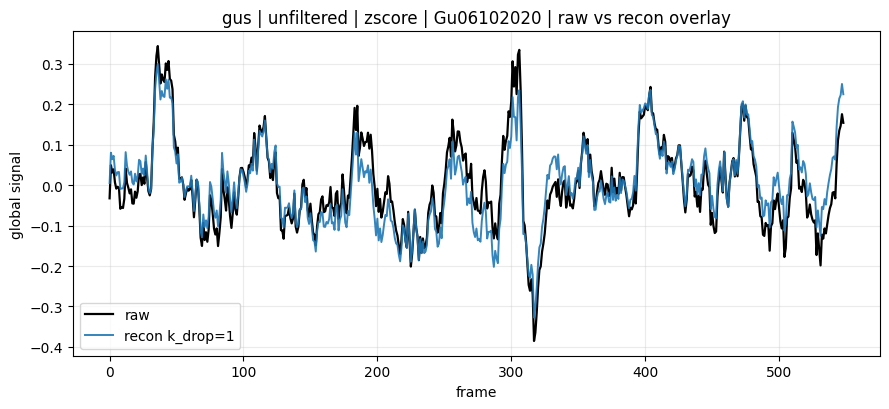

In [17]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])
    rk = (str(subject), str(session_id))
    if rk not in residuals_by_condition:
        continue

    p = residuals_by_condition[rk]
    t = np.arange(len(p["raw_ts"]))

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(t, p["raw_ts"], lw=1.6, color="black", label="raw")
    ax.plot(t, p["recon_ts"], lw=1.4, alpha=0.9, label=f"recon k_drop={p['k_drop_ref']}")
    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | raw vs recon overlay")
    ax.set_xlabel("frame")
    ax.set_ylabel("global signal")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_raw_vs_recon_overlay.png")
    plt.show()


#### residual time series (raw - recon)

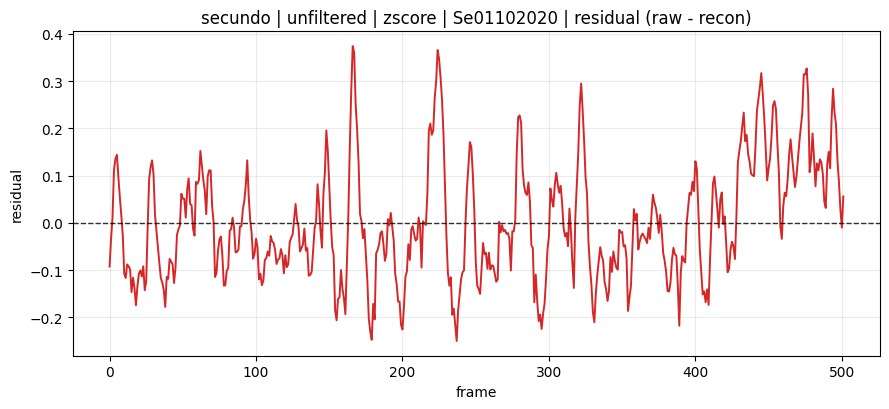

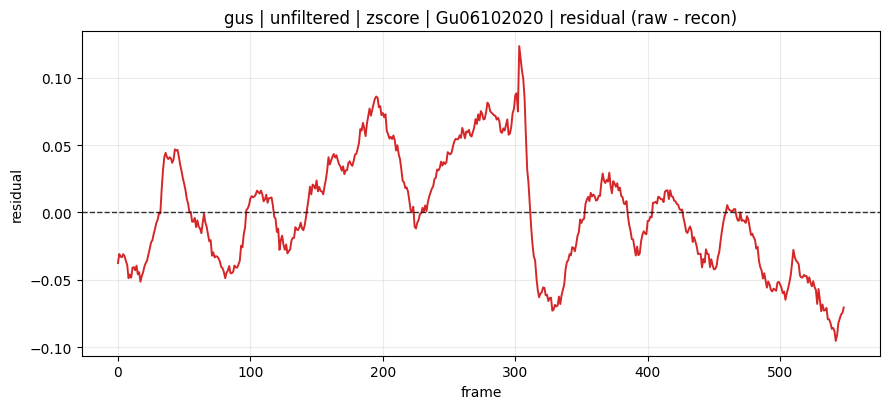

In [18]:
for subject in subjects:
    disp = display_session_by_subject.get(subject)
    if disp is None:
        continue
    session_id = str(disp["session_id"])
    rk = (str(subject), str(session_id))
    if rk not in residuals_by_condition:
        continue

    p = residuals_by_condition[rk]
    t = np.arange(len(p["residual_ts"]))

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(t, p["residual_ts"], lw=1.4, color="tab:red")
    ax.axhline(0.0, color="black", lw=1.0, ls="--", alpha=0.8)
    ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | residual (raw - recon)")
    ax.set_xlabel("frame")
    ax.set_ylabel("residual")
    ax.grid(alpha=0.25)
    fig.tight_layout()

    _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_residual_timeseries.png")
    plt.show()


#### optional PSD sanity (raw, recon, residual)

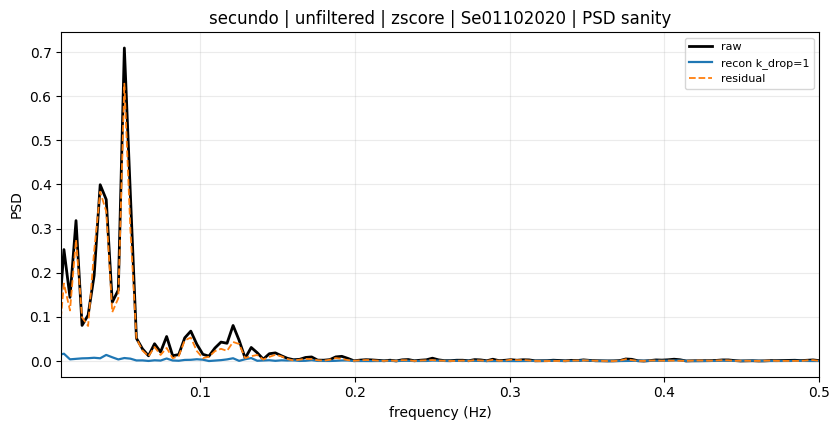

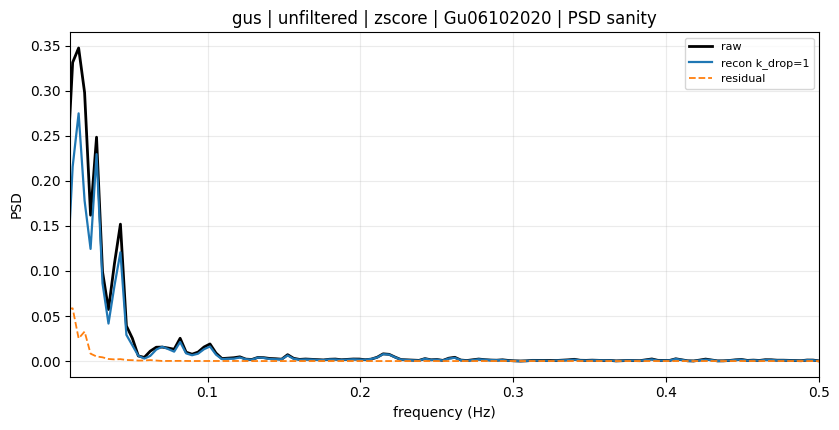

In [19]:
if PSD_ENABLED:
    for subject in subjects:
        disp = display_session_by_subject.get(subject)
        if disp is None:
            continue
        session_id = str(disp["session_id"])
        rk = (str(subject), str(session_id))
        if rk not in psd_by_condition:
            continue

        p = psd_by_condition[rk]
        fig, ax = plt.subplots(figsize=(8.5, 4.4))
        ax.plot(p["f_raw"], p["p_raw"], lw=2.0, color="black", label="raw")
        ax.plot(p["f_recon"], p["p_recon"], lw=1.6, label=f"recon k_drop={p['k_drop_ref']}")
        ax.plot(p["f_residual"], p["p_residual"], lw=1.3, ls="--", label="residual")
        ax.set_xlim(float(p["fmin"]), float(p["fmax"]))
        ax.set_xlabel("frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.set_title(f"{subject} | {data_condition} | {data_variant} | {session_id} | PSD sanity")
        ax.grid(alpha=0.25)
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout()

        _save_fig(fig, f"{_slug(subject)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_psd_sanity.png")
        plt.show()


### Section Outputs
store outputs in variables for later use: recons_by_condition, residuals_by_condition, psd_by_condition

In [20]:
# Section 7 outputs
section7_outputs = {
    "recons_by_condition": recons_by_condition,
    "residuals_by_condition": residuals_by_condition,
    "psd_by_condition": psd_by_condition,
}


---
## Video comparison
This section uses `hf.make_conjoined_video` to compare frames before and after `k_drop = 1`.

In [21]:
# Section 8: QC conjoined video (one example session per subject)
video_cfg = main_params.get("video", {})
VIDEO_ENABLED = bool(video_cfg.get("enabled", True))
VIDEO_N_FRAMES = video_cfg.get("n_frames", 300)
VIDEO_FPS = float(video_cfg.get("fps", 10.0))
VIDEO_PANEL_GAP = int(video_cfg.get("panel_gap_px", 2))
VIDEO_SIGNED_ABS_PCTL = float(video_cfg.get("signed_abs_percentile", 97.0))

video_output_dir = deriv_root / "pca_acf" / "videos"
video_output_dir.mkdir(parents=True, exist_ok=True)

video_results = {}

if not VIDEO_ENABLED:
    print("Video generation disabled in config.")
else:
    for subject in subjects:
        disp = display_session_by_subject.get(subject)
        if disp is None:
            continue

        session_id = str(disp["session_id"])
        subj = str(subject)

        raw_frames = np.asarray(disp["frames"], dtype=np.float32)
        if raw_frames.ndim != 3:
            print(f"[skip video] {subj}/{session_id}: raw frames shape invalid {raw_frames.shape}")
            continue

        k1_key = (subj, session_id, "k_drop_1")

        # recon(k=1) only (explicitly enforce requested comparison)
        recon1_frames = None
        residual_frames = None

        if k1_key in recons_by_condition and "frames" in recons_by_condition[k1_key]:
            recon1_frames = np.asarray(recons_by_condition[k1_key]["frames"], dtype=np.float32)
            Tmin = int(min(raw_frames.shape[0], recon1_frames.shape[0]))
            residual_frames = raw_frames[:Tmin] - recon1_frames[:Tmin]
            raw_frames = raw_frames[:Tmin]
            recon1_frames = recon1_frames[:Tmin]
        else:
            print(f"[skip video] {subj}/{session_id}: missing recon(k=1) frames")
            continue

        panels = [raw_frames, recon1_frames, residual_frames]
        labels = [
            "raw",
            "k_drop =1",
            "residual",
        ]

        out_name = f"{_slug(subj)}_{_slug(data_condition)}_{_slug(data_variant)}_{_slug(session_id)}_qc_conjoined.mp4"
        out_path = video_output_dir / out_name

        try:
            vinfo = hf.make_conjoined_video(
                panels,
                labels,
                str(out_path),
                fps=VIDEO_FPS,
                n_frames=VIDEO_N_FRAMES,
                scaling_mode="shared_from_first",
                signed=[False, False, True],
                signed_abs_percentile=VIDEO_SIGNED_ABS_PCTL,
                panel_gap_px=VIDEO_PANEL_GAP,
            )
            video_results[(subj, session_id)] = {
                "out_path": str(out_path),
                "video_info": vinfo,
            }
            print(f"[video] saved: {out_path}")
        except Exception as e:
            print(f"[video error] {subj}/{session_id}: {e}")

# Section 8 outputs
section8_outputs = {
    "video_results": video_results,
}


[video] saved: c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\pca_acf\videos\secundo_unfiltered_zscore_Se01102020_qc_conjoined.mp4
[video] saved: c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\pca_acf\videos\gus_unfiltered_zscore_Gu06102020_qc_conjoined.mp4
